Retinal Blood Vessel Segmentation using Vessel Enhancement and Deep Learning

Environment setup

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import glob
from skimage.filters import frangi
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A

def set_seed(seed=42):
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  np.random.seed(seed)
  random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [9]:
import pkg_resources

packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "opencv-python",
    "scikit-image",
    "torch",
    "albumentations"
]

with open("requirements.txt", "w") as f:
    for package in packages:
        try:
            version = pkg_resources.get_distribution(package).version
            f.write(f"{package}=={version}\n")
        except pkg_resources.DistributionNotFound:
            print(f"{package} is not installed")

print("requirements.txt generated successfully!")

/tmp/ipykernel_55/968751448.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


requirements.txt generated successfully!


Import Dataset

In [10]:
base_path = "/kaggle/input/datasets/zionfuo/drive2004/DRIVE"

train_image_paths = sorted(glob.glob(base_path + "/training/images/*.tif"))
train_mask_paths  = sorted(glob.glob(base_path + "/training/1st_manual/*.gif"))

print("Training images:", len(train_image_paths))
print("Training masks:", len(train_mask_paths))

Training images: 20
Training masks: 20


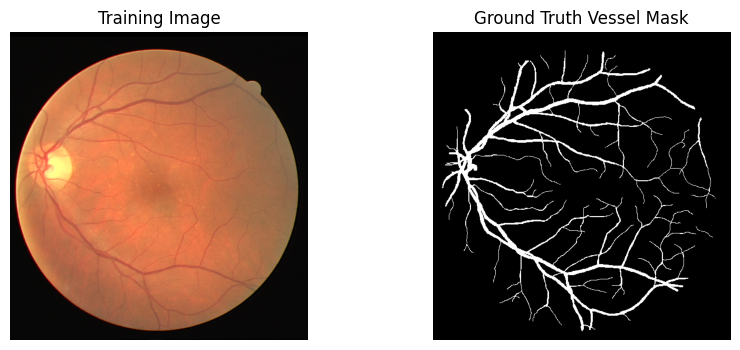

In [11]:
# Pick first training sample
img_path = train_image_paths[0]
mask_path = train_mask_paths[0]

# Read image
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Read mask
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
mask = mask / 255.0

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Training Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Vessel Mask")
plt.axis("off")

plt.show()

Data Preprocessing

In [12]:
# PARAMETERS

PATCH_SIZE = 256
VESSEL_THRESHOLD = 0.02   # 2% vessel pixels required

# AUGMENTATION PIPELINES
train_transform = A.Compose(
[
    A.HorizontalFlip(p=0.5),

    A.Rotate(limit=15, p=0.5),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.3
    ),

    A.GaussNoise(p=0.2)

],
additional_targets={"mask": "mask"}
)

test_transform = A.Compose([])

# DATASET CLASS
class DriveDataset(Dataset):

    def __init__(self, image_paths, mask_paths=None, fov_paths = None, transform=None, use_patches=True):        
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.fov_paths = fov_paths
        self.transform = transform
        self.use_patches = use_patches

    def __len__(self):
        return len(self.image_paths)

    def preprocess(self, image):

        # Green channel extraction
        green = image[:,:,1]

        # CLAHE contrast enhancement
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        clahe_img = clahe.apply(green)

        # Frangi vessel enhancement
        frangi_img = frangi(clahe_img)

        # Normalize to [0,1]
        frangi_img = (frangi_img - frangi_img.min()) / (frangi_img.max() - frangi_img.min() + 1e-8)

        return frangi_img.astype(np.float32)


    def vessel_balanced_patch(self, image, mask):

        h, w = image.shape

        ph = PATCH_SIZE
        pw = PATCH_SIZE

        max_attempts = 15

        for _ in range(max_attempts):

            x = np.random.randint(0, w - pw)
            y = np.random.randint(0, h - ph)

            img_patch = image[y:y+ph, x:x+pw]
            mask_patch = mask[y:y+ph, x:x+pw]

            vessel_ratio = np.mean(mask_patch)

            if vessel_ratio > VESSEL_THRESHOLD:
                return img_patch, mask_patch

        # fallback if vessel patch not found
        return img_patch, mask_patch


    def __getitem__(self, idx):

        img_path = self.image_paths[idx]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = self.preprocess(image)


        if self.mask_paths is not None:

            mask_path = self.mask_paths[idx]

            mask = cv2.imread(mask_path, 0)

            # convert mask to binary
            mask = mask / 255.0
            mask = mask.astype(np.float32)

            # VESSEL BALANCED PATCH SAMPLING
            if self.use_patches:
                image, mask = self.vessel_balanced_patch(image, mask)
        else:
            mask = None

        
        if self.fov_paths is not None:
            fov = cv2.imread(self.fov_paths[idx], cv2.IMREAD_GRAYSCALE)
            fov = (fov / 255.0).astype(np.float32)


        # AUGMENTATION
        if self.transform:

            if mask is not None:

                augmented = self.transform(image=image, mask=mask)

                image = augmented["image"]
                mask = augmented["mask"]

            else:

                augmented = self.transform(image=image)
                image = augmented["image"]


        # CONVERT TO TENSOR
        image = torch.tensor(image).unsqueeze(0)

        if mask is not None:
            mask = torch.tensor(mask).unsqueeze(0)
            if self.fov_paths is not None:
                fov = torch.tensor(fov).unsqueeze(0)
                return image, mask, fov
            return image, mask

        return image

# DATASET PATHS
train_images = sorted(glob.glob(
"/kaggle/input/datasets/zionfuo/drive2004/DRIVE/training/images/*.tif"
))

train_masks = sorted(glob.glob(
"/kaggle/input/datasets/zionfuo/drive2004/DRIVE/training/1st_manual/*.gif"
))

test_images = sorted(glob.glob(
"/kaggle/input/datasets/zionfuo/drive2004/DRIVE/test/images/*.tif"
))
test_masks = sorted(glob.glob(
"/kaggle/input/datasets/zionfuo/drive2004/DRIVE/test/1st_manual/*.gif"
))
test_fov = sorted(glob.glob(
"/kaggle/input/datasets/zionfuo/drive2004/DRIVE/test/mask/*.gif"
))

# DATASET OBJECTS
train_dataset = DriveDataset(
    train_images,
    train_masks,
    transform=train_transform,
    use_patches=True
)

test_dataset = DriveDataset(
    test_images,
    test_masks,
    fov_paths = test_fov,
    transform=test_transform,
    use_patches=False
)

# DATALOADERS
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)

# TEST SAMPLE

image, mask = train_dataset[0]

print("Image tensor shape:", image.shape)
print("Mask tensor shape:", mask.shape)

Image tensor shape: torch.Size([1, 256, 256])
Mask tensor shape: torch.Size([1, 256, 256])


U-Net Model Defination

In [13]:
# DOUBLE CONV BLOCK
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)

        )

    def forward(self, x):
        return self.conv(x)

# DOWN BLOCK
class Down(nn.Module):

    def __init__(self, in_channels, out_channels):
        super(Down, self).__init__()

        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

# UP BLOCK
class Up(nn.Module):

    def __init__(self, in_channels, out_channels):
        super(Up, self).__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            in_channels // 2,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):

        x1 = self.up(x1)

        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(
            x1,
            [diffX // 2, diffX - diffX // 2,
             diffY // 2, diffY - diffY // 2]
        )

        x = torch.cat([x2, x1], dim=1)

        return self.conv(x)

# OUTPUT LAYER
class OutConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()

        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

# U-NET MODEL
class UNet(nn.Module):

    def __init__(self, n_channels=1, n_classes=1):
        super(UNet, self).__init__()

        self.inc = DoubleConv(n_channels, 64)

        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)

        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)

        self.outc = OutConv(64, n_classes)


    def forward(self, x):

        x1 = self.inc(x)

        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x)

        return logits

Training Setup

In [14]:
#Loss function
class DiceLoss(nn.Module):

    def __init__(self, smooth=1):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)

        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()

        dice = (2. * intersection + self.smooth) / (
            probs.sum() + targets.sum() + self.smooth
        )

        return 1 - dice

bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

def combined_loss(pred, target):

    bce = bce_loss(pred, target)
    dice = dice_loss(pred, target)

    return bce + dice

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(n_channels=1, n_classes=1)
model = model.to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=4
)

Training

In [16]:
num_epochs = 40

best_loss = float("inf")

for epoch in range(num_epochs):

    model.train()
    epoch_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        # forward
        outputs = model(images)

        # loss
        loss = combined_loss(outputs, masks)

        # backward
        loss.backward()

        # update
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

    # Step scheduler
    scheduler.step(avg_loss)

    # Save best model
    if avg_loss < best_loss:
        best_loss = avg_loss

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss": best_loss
        }, "best_unet_drive_model.pth")

        print(f"Best model saved at epoch {epoch+1} with loss {best_loss:.4f}")

Epoch [1/40] Loss: 1.4566
Best model saved at epoch 1 with loss 1.4566
Epoch [2/40] Loss: 1.4016
Best model saved at epoch 2 with loss 1.4016
Epoch [3/40] Loss: 1.3770
Best model saved at epoch 3 with loss 1.3770
Epoch [4/40] Loss: 1.3727
Best model saved at epoch 4 with loss 1.3727
Epoch [5/40] Loss: 1.3128
Best model saved at epoch 5 with loss 1.3128
Epoch [6/40] Loss: 1.2578
Best model saved at epoch 6 with loss 1.2578
Epoch [7/40] Loss: 1.2426
Best model saved at epoch 7 with loss 1.2426
Epoch [8/40] Loss: 1.2463
Epoch [9/40] Loss: 1.2098
Best model saved at epoch 9 with loss 1.2098
Epoch [10/40] Loss: 1.1686
Best model saved at epoch 10 with loss 1.1686
Epoch [11/40] Loss: 1.1208
Best model saved at epoch 11 with loss 1.1208
Epoch [12/40] Loss: 1.1532
Epoch [13/40] Loss: 1.1286
Epoch [14/40] Loss: 1.1146
Best model saved at epoch 14 with loss 1.1146
Epoch [15/40] Loss: 1.0981
Best model saved at epoch 15 with loss 1.0981
Epoch [16/40] Loss: 1.1190
Epoch [17/40] Loss: 1.0560
Best m

In [17]:
checkpoint = torch.load("best_unet_drive_model.pth")
model.load_state_dict(checkpoint["model_state_dict"])

print("Loaded best model from epoch:", checkpoint["epoch"])

Loaded best model from epoch: 39


Evaluation

In [26]:
model.eval()

total_dice = 0

with torch.no_grad():

    for images, masks, fovs in test_loader:

        images = images.to(device)
        masks = masks.to(device)
        fovs = fovs.to(device)

        outputs = model(images)

        preds = torch.sigmoid(outputs)
        preds = (preds > 0.5).float()

        # ---- Morphological cleanup ----
        preds_np = preds.cpu().numpy()

        kernel = np.ones((3,3), np.uint8)

        for i in range(preds_np.shape[0]):
            preds_np[i,0] = cv2.morphologyEx(preds_np[i,0].astype(np.uint8), cv2.MORPH_CLOSE, kernel)

        preds = torch.tensor(preds_np).to(device)

        # Apply FOV mask
        preds = preds * fovs
        masks = masks * fovs

        intersection = (preds * masks).sum()

        dice = (2 * intersection) / (preds.sum() + masks.sum() + 1e-8)

        total_dice += dice.item()

avg_dice = total_dice / len(test_loader)

print("Test Dice Score:", avg_dice)

Test Dice Score: 0.7421292066574097


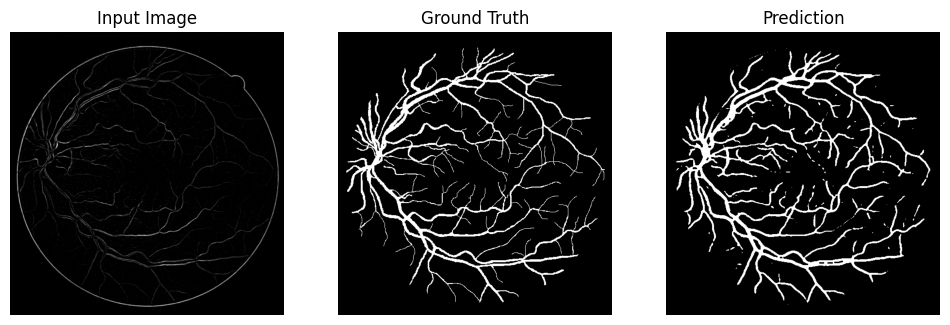

In [30]:
model.eval()

images, masks, fovs = next(iter(test_loader))

images = images.to(device)
masks = masks.to(device)
fovs = fovs.to(device)

with torch.no_grad():
    outputs = model(images)

# Convert logits → probabilities
preds = torch.sigmoid(outputs)

# Apply best threshold
preds = (preds > 0.5).float()

# Morphological cleanup
pred_np = preds[0].cpu().squeeze().numpy().astype(np.uint8)
kernel = np.ones((3,3), np.uint8)
pred_clean = cv2.morphologyEx(pred_np, cv2.MORPH_CLOSE, kernel)

# Convert back to tensor
pred_clean = torch.tensor(pred_clean).to(device)

# Apply FOV mask
pred_clean = pred_clean * fovs[0]
mask = masks[0] * fovs[0]

# Move to CPU for plotting
image = images[0].cpu().squeeze()
mask = mask.cpu().squeeze()
pred = pred_clean.cpu().squeeze()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(image, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred, cmap='gray')
plt.axis("off")

plt.show()